Link to original dataset: https://www.kaggle.com/datasets/mathchi/hitters-baseball-data

In [2]:
import pandas as pd
originalDF = pd.read_csv("Hitters.csv")
backupDF = originalDF.copy()

In [4]:
originalDF.info()
originalDF.isna().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [6]:
# there were 59 missing values for the salary column
cleanDF = originalDF.dropna()
cleanDF.isna().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

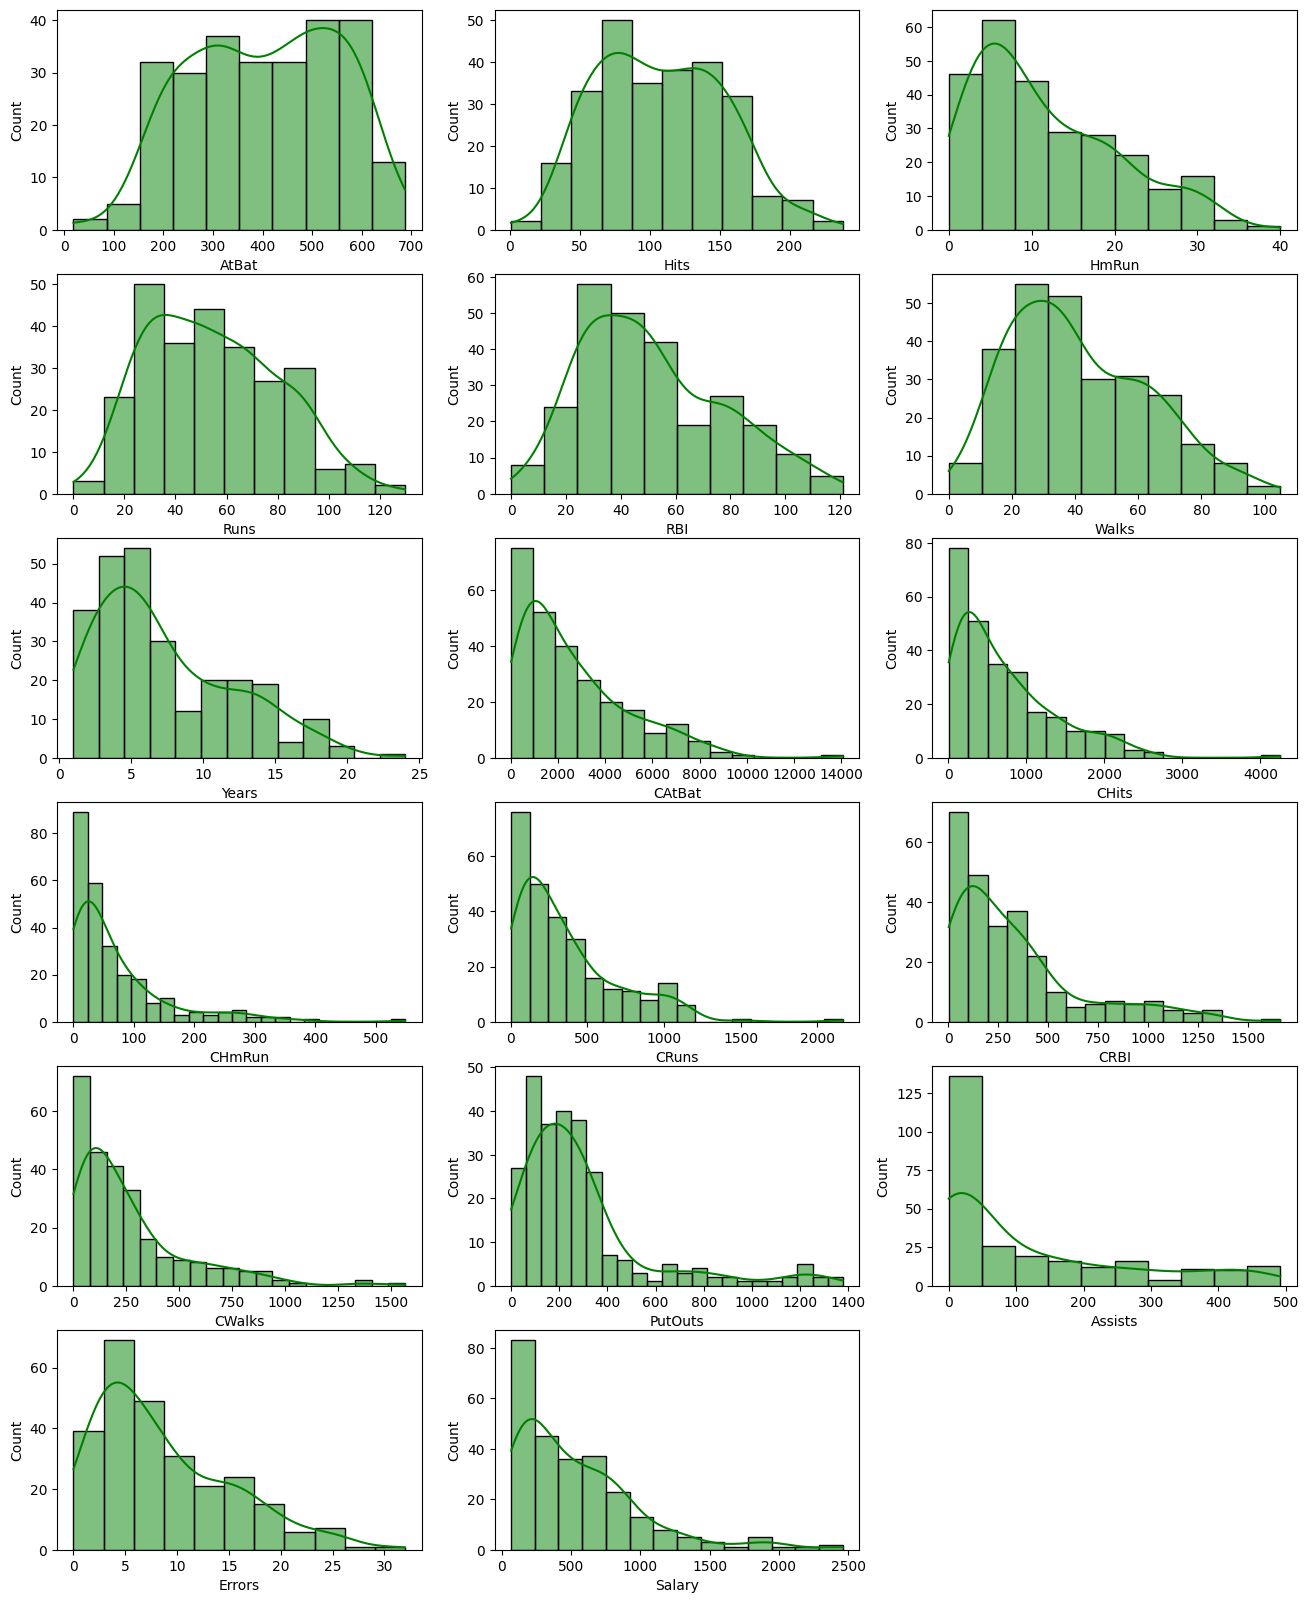

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numericCols = cleanDF.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 20))

for i, col in enumerate(numericCols, 1):
    plt.subplot(6, 3, i)
    sns.histplot(cleanDF[col], kde=True, color='green')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.show()


/var/folders/7y/_9f0g61d1dn47z7sdfnvv7f40000gn/T/ipykernel_91833/1288946967.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleanDF, x=col, palette="Set2")
/var/folders/7y/_9f0g61d1dn47z7sdfnvv7f40000gn/T/ipykernel_91833/1288946967.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleanDF, x=col, palette="Set2")
/var/folders/7y/_9f0g61d1dn47z7sdfnvv7f40000gn/T/ipykernel_91833/1288946967.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleanDF, x=col, palette="Set2")


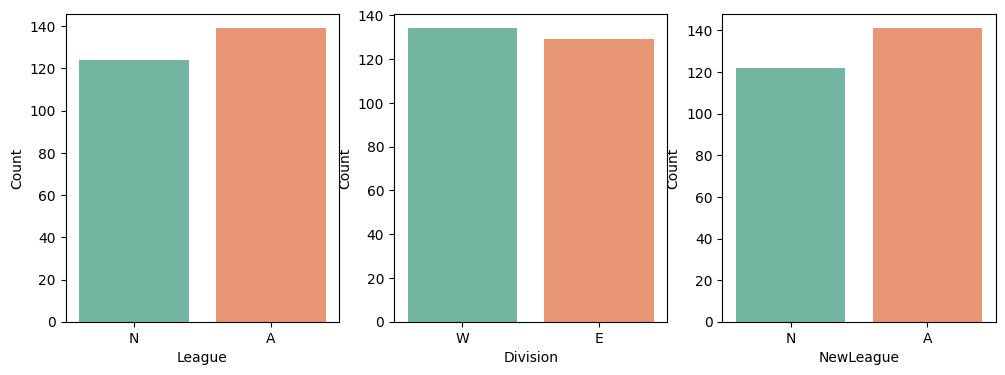

In [ ]:
categoricalCols = ["League", "Division", "NewLeague"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(categoricalCols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=cleanDF, x=col, palette="Set2")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.show()


In [10]:
# copying the cleaned dataset
cleanedDF = cleanDF.copy()

# identifying categorical columns
categoricalCols = ["League", "Division", "NewLeague"]

from sklearn.preprocessing import OneHotEncoder

# creating the encoder
encoder = OneHotEncoder(sparse_output=False)

# fitting and transforming the categorical columns
encodedData = encoder.fit_transform(cleanedDF[categoricalCols])

# getting the new column names
encodedColumns = encoder.get_feature_names_out(categoricalCols)

# creating a dataframe for the encoded columns
oneHotDF = pd.DataFrame(encodedData, columns=encodedColumns)
oneHotDF.index = cleanedDF.index

# dropping the original categorical columns
cleanedDF = cleanedDF.drop(columns=categoricalCols)

# adding the encoded columns to the dataframe
cleanedDF = pd.concat([cleanedDF, oneHotDF], axis=1)

cleanedDF.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,...,632,43,10,475.0,0.0,1.0,0.0,1.0,0.0,1.0
2,479,130,18,66,72,76,3,1624,457,63,...,880,82,14,480.0,1.0,0.0,0.0,1.0,1.0,0.0
3,496,141,20,65,78,37,11,5628,1575,225,...,200,11,3,500.0,0.0,1.0,1.0,0.0,0.0,1.0
4,321,87,10,39,42,30,2,396,101,12,...,805,40,4,91.5,0.0,1.0,1.0,0.0,0.0,1.0
5,594,169,4,74,51,35,11,4408,1133,19,...,282,421,25,750.0,1.0,0.0,0.0,1.0,1.0,0.0


In [15]:
# making a copy before removing outliers
noOutlierDF = cleanDF.copy()

# identifying numeric columns
numericCols = [
    "AtBat","Hits","HmRun","Runs","RBI","Walks","Years",
    "CAtBat","CHits","CHmRun","CRuns","CRBI","CWalks",
    "PutOuts","Assists","Errors","Salary"
]

rowsBefore = noOutlierDF.shape[0]

# using a more conservative IQR multiplier (3.0 instead of 1.5)
for col in numericCols:
    Q1 = noOutlierDF[col].quantile(0.25)
    Q3 = noOutlierDF[col].quantile(0.75)
    IQR = Q3 - Q1

    lowerBound = Q1 - 3.0 * IQR
    upperBound = Q3 + 3.0 * IQR

    noOutlierDF = noOutlierDF[(noOutlierDF[col] >= lowerBound) & (noOutlierDF[col] <= upperBound)]

rowsAfter = noOutlierDF.shape[0]

print("Rows before removing outliers:", rowsBefore)
print("Rows after removing outliers:", rowsAfter)



Rows before removing outliers: 263
Rows after removing outliers: 244


Removed 19 rows. I went with a more conservative IQR removal because outliers are one of the attributes that make determining MLB salaries important, so I didn't want to remove too many.

In [16]:
# updating one hot encoding after outlier removal

categoricalCols = ["League", "Division", "NewLeague"]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encodedData = encoder.fit_transform(noOutlierDF[categoricalCols])
encodedColumns = encoder.get_feature_names_out(categoricalCols)

oneHotDF = pd.DataFrame(encodedData, columns=encodedColumns)
oneHotDF.index = noOutlierDF.index

# dropping original categorical columns
noOutlierDF = noOutlierDF.drop(columns=categoricalCols)

# adding encoded columns
noOutlierDF = pd.concat([noOutlierDF, oneHotDF], axis=1)

noOutlierDF.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,...,632,43,10,475.0,0.0,1.0,0.0,1.0,0.0,1.0
2,479,130,18,66,72,76,3,1624,457,63,...,880,82,14,480.0,1.0,0.0,0.0,1.0,1.0,0.0
3,496,141,20,65,78,37,11,5628,1575,225,...,200,11,3,500.0,0.0,1.0,1.0,0.0,0.0,1.0
4,321,87,10,39,42,30,2,396,101,12,...,805,40,4,91.5,0.0,1.0,1.0,0.0,0.0,1.0
5,594,169,4,74,51,35,11,4408,1133,19,...,282,421,25,750.0,1.0,0.0,0.0,1.0,1.0,0.0


In [17]:
noOutlierDF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 1 to 321
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        244 non-null    int64  
 1   Hits         244 non-null    int64  
 2   HmRun        244 non-null    int64  
 3   Runs         244 non-null    int64  
 4   RBI          244 non-null    int64  
 5   Walks        244 non-null    int64  
 6   Years        244 non-null    int64  
 7   CAtBat       244 non-null    int64  
 8   CHits        244 non-null    int64  
 9   CHmRun       244 non-null    int64  
 10  CRuns        244 non-null    int64  
 11  CRBI         244 non-null    int64  
 12  CWalks       244 non-null    int64  
 13  PutOuts      244 non-null    int64  
 14  Assists      244 non-null    int64  
 15  Errors       244 non-null    int64  
 16  Salary       244 non-null    float64
 17  League_A     244 non-null    float64
 18  League_N     244 non-null    float64
 19  Division_E   

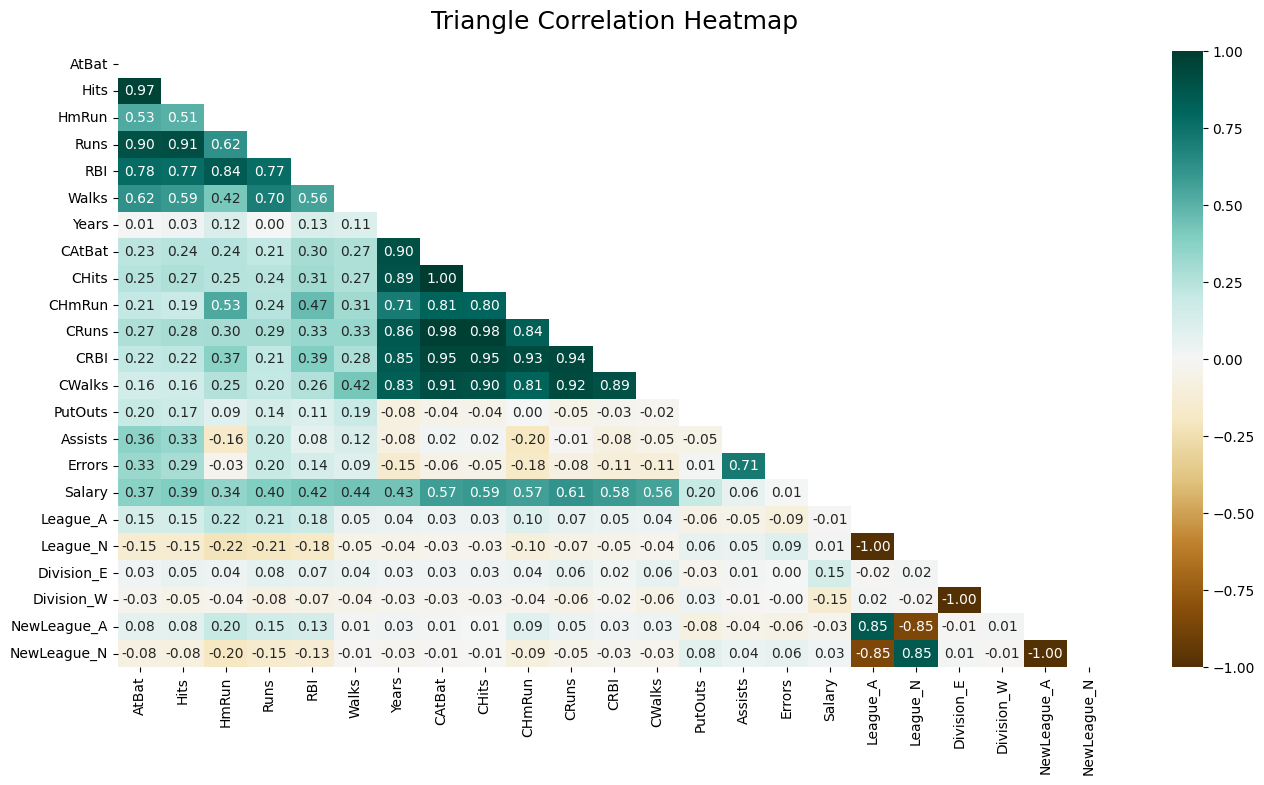

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

mask = np.triu(np.ones_like(noOutlierDF.corr(), dtype=bool))

heatmap = sns.heatmap(
    noOutlierDF.corr(),
    mask=mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    cmap='BrBG'
)

heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16)

plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
from sklearn.model_selection import train_test_split

# splitting into features and target
X = noOutlierDF.drop("Salary", axis=1)
y = noOutlierDF["Salary"]

xTrain, xTest, yTrain, yTest = train_test_split(
    X, y,
    test_size=0.05,
    shuffle=True
)

xTrain.shape, xTest.shape


((231, 22), (13, 22))

In [20]:
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
xColNames = xTrain.columns.values.tolist()

xTrainScaled = xScaler.fit_transform(xTrain[xColNames])
xTestScaled = xScaler.transform(xTest[xColNames])


In [ ]:
# note for future jace: the data has been split and then each set has been scaled
# the next step is to start training the models (it has to be 6 dont forget)